# Phantom-Kernel — a quantitative teardown 🔬
### Survival-function kernel · per-order likelihood model selection · static-`k` spread error · bootstrap-Sharpe tournament

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Optimal--spread: Misattributed](https://img.shields.io/badge/Optimal--spread-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* The Avellaneda-Stoikov optimum, mechanised and falsified on a seed-fixed order-flow simulator.

> ⚠️ **Not investment advice.** Runs offline on the simulator (no network, no data); the frozen 5-seed numbers and fingerprint are in [`docs/results.md`](../docs/results.md), the heavy-tail confirmation on real Binance books in [`docs/results_real.md`](../docs/results_real.md). Methods: per-order likelihood model selection (AIC + Vuong), Clauset-Shalizi-Newman / Vuong power-law tests, bootstrap Sharpe CIs — see [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition — so this notebook still reads even if you skim the maths. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (phantom_kernel/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from phantom_kernel import sim, estimator, strategies, experiments as ex

# Smaller draws than docs/results.md so the notebook executes quickly; the story is identical.
NORD, NSTEP = 200_000, 30_000
print("two worlds:", sim.WORLD_A.name, "|", sim.WORLD_B.name)


two worlds: A (textbook) | B (frictions)


## 1 · The Claim, as two hypotheses

**H1 (the kernel):** order reach is exponential, so `λ(δ) = A·e^(−kδ)` with stable `k` — reject if a power law fits better (AIC) or `k` is regime-unstable.
**H2 (the payoff):** the AS skew + closed-form spread beats naive quoters — reject if a trivial inventory clamp matches it. The key identity: a quote at distance `δ` fills iff an order *reaches* `δ`, so `λ(δ) = Λ·S_reach(δ)` — **the kernel is the survival function of order reach.** Exponential reach ⟺ AS exactly; heavy-tailed ⟹ power law.

> 💡 **In plain words** — the model assumes orders fade away in a tidy exponential as you quote further from the mid. We're really asking two things: *does that fade have the right shape?* (H1) and *if it doesn't, does the model still make money?* (H2).

## 2 · So What? — it's a question of attribution

`k` appears **only** in the spread's arrival term `(2/γ)·ln(1+γ/k)`; the reservation price `r = s − q·γ·σ²·(T−t)` has no `k`. So if the edge is the skew, a wrong `k` is nearly free; if it's the spread width, a wrong `k` is ruinous. The study decomposes where the P&L lives.

## 3 · How We'd Know — pre-registered, machinery validated first

World A must validate the estimator (recover the planted `k`) or any World-B failure is a bug, not a finding:

In [2]:
rec = ex.estimator_recovery(n_orders=NORD, seed=0)
print('estimator recovery (World A):', rec)
assert abs(rec['rel_error_pct']) < 3 and rec['r2'] > 0.99, 'machinery must recover k'

estimator recovery (World A): {'k_true': 0.6, 'k_recovered': 0.5984, 'rel_error_pct': -0.27, 'r2': 0.99998}


## 4 · The Teardown

**(a) The kernel, on a log axis** — straight where reach is exponential, curved where it's heavy-tailed.

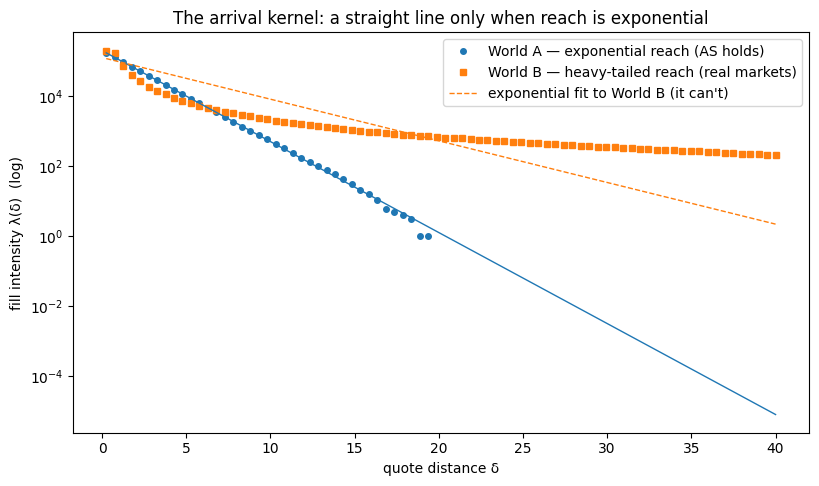

World B fits a straight exponential with R² = 0.736 — the points curve away from it.


In [3]:
# The money figure: the arrival kernel on a log axis. Exponential reach -> a straight line
# (AS holds). Heavy-tailed reach -> a curve the exponential cannot fit.
d = ex.default_deltas()
ca = sim.fill_counts(sim.WORLD_A, d, n_orders=NORD, seed=0)
cb = sim.fill_counts(sim.WORLD_B, d, n_orders=NORD, seed=0)
fa, fb = estimator.fit_exponential(d, ca), estimator.fit_exponential(d, cb)
fig, ax = plt.subplots()
ma, mb = ca > 0, cb > 0
ax.semilogy(d[ma], ca[ma], "o", ms=4, label="World A — exponential reach (AS holds)")
ax.semilogy(d[mb], cb[mb], "s", ms=4, label="World B — heavy-tailed reach (real markets)")
ax.semilogy(d, fa["A"] * np.exp(-fa["k"] * d), "-", lw=1, color="C0")
ax.semilogy(d, fb["A"] * np.exp(-fb["k"] * d), "--", lw=1, color="C1",
            label="exponential fit to World B (it can't)")
ax.set_xlabel("quote distance δ"); ax.set_ylabel("fill intensity λ(δ)  (log)")
ax.set_title("The arrival kernel: a straight line only when reach is exponential")
ax.legend(); plt.show()
print("World B fits a straight exponential with R² =", round(fb["r2"], 3),
      "— the points curve away from it.")


**(b) Model selection — each order counted once.** The binned weighted-R² fits are *descriptive* (they recover the `k` a desk would plug in and draw the curve); the *verdict* is a **per-observation likelihood test** on the raw execution depths: exponential (1-parameter MLE) vs power law (Pareto, 2-parameter MLE), scored by AIC (`aic_gap > 0` ⟹ power law preferred) and **Vuong's** non-nested statistic. (An earlier draft scored the 80 *cumulative* fill counts as independent Poissons — nested counts of the same orders are neither, so that gap scaled with the sample size; restated in [`docs/results.md`](../docs/results.md).) World A: exponential. World B: power law, decisively — and the α=1.2 row is the labelled *stress* case, heavier than any tail the study measured.

> 💡 **In plain words** — line up two candidate shapes against the data and ask which the evidence prefers, letting each order vote exactly once. In the textbook world the exponential wins (it's the truth there); in the realistic world the heavy-tailed power law wins by a landslide.

In [4]:
ex.kernel_gof_table(n_orders=NORD, seed=0)

,r2_exp,r2_pow,k_exp,alpha_mle,aic_gap,ll_per_order,V,winner
A (textbook),1.0000,0.7558,0.5984,0.0711,"-825,948.3000",-2.0649,"-1,069.9000",exponential
B (frictions),0.7363,0.8919,0.2739,1.7023,"331,652.2000",0.8291,171.1000,power-law
B-stress (alpha=1.2),0.6812,0.9996,0.1980,1.2016,"407,572.2000",1.0189,35.8000,power-law


**(b′) The same test on real order books.** The simulator only *asserts* heavy-tailed reach; we confirm it. On four Binance USD-M futures books (TRX/XRP/ADA/LTC, 2024-01-15) the rigorous **Clauset–Shalizi–Newman + Vuong** tail test (run offline here from the committed [`docs/results_real.md`](../docs/results_real.md), reproducible via [`examples/confirm_heavy_tail.py`](../examples/confirm_heavy_tail.py)) calls order **size** power-law on **4/4** markets (Vuong V 2.8–5.5, p<0.01, α≈3.0–3.4) and **|price−mid|** power-law on **3/4** (the 4th merely *inconclusive*, never a clean exponential). The measured price-distance tails translate to survival exponents ≈1.4–3.2 — the band World B's α=1.7 is drawn from. One-day snapshot, four symbols, one venue: it supports the heavy-tail premise; the verdict itself is earned on the simulator.

> 💡 **In plain words** — this isn't a quirk of our toy market: real crypto order books have the fat tail too, so the exponential the model leans on is the wrong shape out in the wild, not just in the lab.

**(c) The phantom parameter** — four regimes with `k` spanning 4×. Each regime's `k` is recovered exactly, but base AS fits one static `k`; at the session length the study actually trades (T=600, evaluated mid-session) the gap mis-prices the spread by **up to ~41%** — and by up to ~163% at T=1, where the `k`-term is essentially the whole spread (the worst case by construction, quoted only as a bound).

In [5]:
ki = ex.k_instability(seed=0)
import pprint; pprint.pprint(ki)

{'bound_T1': {'eval_t': 0.0,
              'horizon': 1.0,
              'max_abs_spread_pct_error': 162.53,
              'spread_pct_error_per_regime': [-26.43, 36.97, 99.92, 162.53]},
 'eval_t': 300.0,
 'horizon': 600.0,
 'k_pooled_static': 0.4247,
 'k_recovered_per_regime': [0.2993, 0.6044, 0.8981, 1.2004],
 'k_true': [0.3, 0.6, 0.9, 1.2],
 'k_true_ratio': 4.0,
 'max_abs_spread_pct_error': 41.05,
 'spread_pct_error_per_regime': [-14.45, 14.53, 30.71, 41.05]}


**(d) The tournament** — four quoters, one shared exogenous order stream per world. The naive baselines quote at AS's own mid-session spread width, so the comparison is pure skew/clamp logic. `pnl_sharpe` carries a bootstrap CI.

In [6]:
tA = ex.tournament(sim.WORLD_A, n_steps=NSTEP, seed=0)
tB = ex.tournament(sim.WORLD_B, n_steps=NSTEP, seed=0)
print('World A (k_as=%.3f):' % tA.attrs['k_as']); print(tA.to_string()); print()
print('World B (k_as=%.3f):' % tB.attrs['k_as']); print(tB.to_string())

World A (k_as=0.600):
                     terminal_pnl  pnl_sharpe  ci_lo  ci_hi  inv_std  inv_absmax    n_fills  n_adverse
AS (fixed)            10,089.0300      3.1700 2.7620 3.8430   0.8000      5.0000 6,344.0000     0.0000
AS (adaptive vol)     10,174.4100      3.2020 2.8040 3.8820   0.8100      5.0000 6,400.0000     0.0000
Symmetric (no skew)   12,442.1300      3.4730 2.9970 4.1860  18.1700     76.0000 4,523.0000     0.0000
Inventory clamp       12,285.5700      4.7500 4.2840 5.4550  12.3600     30.0000 4,477.0000     0.0000

World B (k_as=0.272):
                     terminal_pnl  pnl_sharpe  ci_lo  ci_hi  inv_std  inv_absmax    n_fills  n_adverse
AS (fixed)             9,301.0900      2.0890 1.8250 2.5190   0.8300      6.0000 3,523.0000 2,445.0000
AS (adaptive vol)        198.5500      0.1750 0.1350 0.3190   0.1000      4.0000    69.0000    35.0000
Symmetric (no skew)    9,516.2300      0.1880 0.0220 0.3610  26.3600     96.0000 2,054.0000 1,338.0000
Inventory clamp        7,849

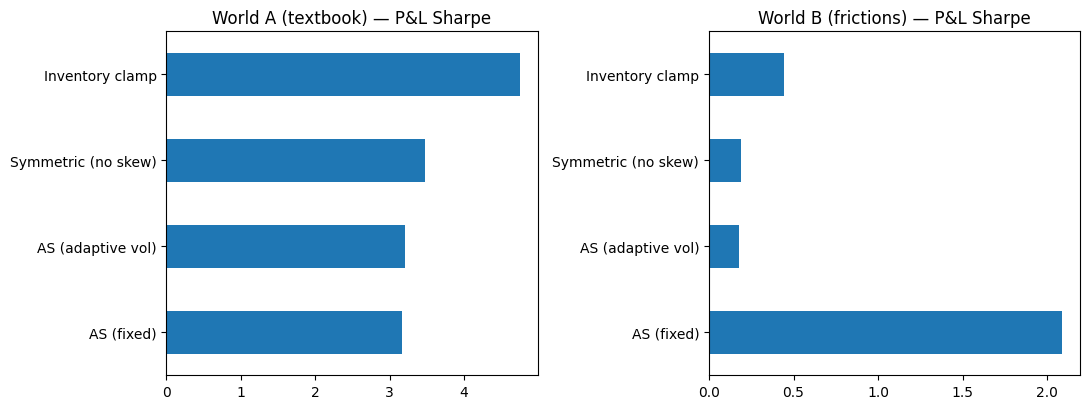

In [7]:
# Sharpe bars, both worlds side by side.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)
for ax, t, title in [(axes[0], tA, sim.WORLD_A.name), (axes[1], tB, sim.WORLD_B.name)]:
    t['pnl_sharpe'].plot(kind='barh', ax=ax)
    ax.set_title(f'World {title} — P&L Sharpe'); ax.axvline(0, color='k', lw=0.5)
plt.tight_layout(); plt.show()

Note the inversion: in World A the **clamp** tops the chart (elaborate inventory control is over-engineering when inventory is cheap); in World B **AS (fixed)** tops it while **AS (adaptive vol)** sits near zero — the rolling-vol fix blown out by jumps. AS wins World B on a *wrong* `k`, because the skew (which carries no `k`) is what's doing the work.

> 💡 **In plain words** — when markets are calm, the elaborate model is *out-traded by four lines of code* that just stop buying when you're too long. It only earns its keep when prices jump and carrying inventory genuinely hurts — and even then, what saves it is the inventory lean, not the famous spread formula.

**(e) The k-ablation** — the decisive experiment for the MISATTRIBUTED stamp. Same AS quoter, same World-B flow, run at the study's own session length (T=600); only `k` swaps between the two calibrations the study puts on the table — the textbook **0.6** and the phantom fitted on World B's own fills (~2.2× apart, hence a materially different quoted width).

In [8]:
ab = ex.k_ablation(sim.WORLD_B, seeds=(0, 1), n_steps=60_000)
print('fitted phantom k =', round(ab.attrs['k_fit'], 4))
print(ab.round(3).to_string())

fitted phantom k = 0.2725
       sharpe k=0.600 (textbook)  pnl k=0.600 (textbook)  sharpe k=0.272 (fitted on B)  pnl k=0.272 (fitted on B)
seed0                     1.5090             15,009.1000                        1.5030                13,525.9000
seed1                     1.5340             15,053.9000                        1.4850                13,160.2000
mean                      1.5220             15,031.5000                        1.4940                13,343.0500


The risk-adjusted P&L **doesn't move** (the frozen 5-seed means in [`docs/results.md`](../docs/results.md): **1.516 vs 1.514**). A ~2.2× error in the model's load-bearing parameter is P&L-neutral at the study's horizon — direct proof that AS's World-B win comes from the `k`-free skew, not the kernel-calibrated width.

> 💡 **In plain words** — we grabbed the model's famous dial, turned it by a factor of two, and the bottom line didn't notice. The dial isn't connected to the part that makes the money.

**(f) Seed-robustness** — the orderings are not a single-draw fluke (5 seeds; the frozen table is in `docs/results.md`).

In [9]:
ex.tournament_multiseed(sim.WORLD_B, seeds=(0, 1, 2)).round(3)

,AS (fixed),AS (adaptive vol),Symmetric (no skew),Inventory clamp
seed0,1.5030,0.1470,0.2900,0.3520
seed1,1.4500,0.1200,0.1430,0.3310
seed2,1.5450,0.1650,0.2590,0.3810
mean,1.4990,0.1440,0.2310,0.3550


## 5 · The Verdict

**Signal NONE** — World-B reach prefers the power law by **~0.83 nats per order** (frozen 400k-order run: AIC gap +664k, Vuong V = +220); a static `k` mis-prices the spread by **41%** at the study's own horizon (163% at the T=1 bound). **Tradability FRAGILE** — a clamp beats AS in World A (frozen 5-seed Sharpe 3.27 vs 1.59); AS wins World B (1.50) but the rolling-vol fix collapses (0.15). **Optimal spread MISATTRIBUTED** — proven by ablation: textbook `k` vs fitted phantom, World-B Sharpe 1.516 vs 1.514. The value is in the `k`-free skew. (Frozen 5-seed numbers + fingerprint: `docs/results.md`; real-data heavy-tail check: `docs/results_real.md`.)

> 💡 **In plain words** — the headline equation everyone copies rests on a false assumption *and* isn't where the money is. Keep the inventory lean; treat the spread formula as a rough rule of thumb, not a theorem.

## 6 · Could You Trade It?

Deploy `r = s − q·γ·σ²·(T−t)` (robust, `k`-free) for inventory control; set the half-spread from a **jump-robust** realised vol, not `(1/γ)ln(1+γ/k)`, since `k` is the phantom. Save the GLT bounds / Cartea–Jaimungal adverse-selection term for venues with material informed flow — World B shows that's exactly where the skew saves you.

## 7 · Going Further

- **Heavy tail on a real book — done.** Confirmed on 4 Binance markets (`examples/confirm_heavy_tail.py` → `docs/results_real.md`); next is a **multi-day / multi-venue** sweep and a fit *in ticks* to remove price-discreteness noise.
- **Jump-robust adaptive vol — worked** ([`docs/extension.md`](../docs/extension.md)): bipower variation *mitigates but does not rescue* the rolling-vol fix (World-B Sharpe 0.15→0.23, still ≪ fixed-σ 1.50) — adapting spread *width* is the wrong lever, which sharpens the core verdict.
- The **GLT** closed form with hard inventory bounds vs the clamp.
- A **Cartea–Jaimungal** adverse-selection spread term.
- A **γ-sweep** to map where the skew's P&L cost stops exceeding its risk saving.
- A **multi-day / multi-venue** real-data sweep (tail exponents, tick-space fit).